<a href="https://colab.research.google.com/github/mSangaraju/sales-data-analysis/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis

This project analyzes sales data to identify revenue trends, profitability, top-performing products, regional performance, and customer behavior.

**Tools:** Python, Pandas, Matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv')
df.head()

,order_id,order_date,region,category,product,quantity,unit_price,unit_cost,customer_id,payment_method
0,ORD0239,2025-01-01,West,Office Supplies,Printer Paper,6,16.99,9.0,C1016,Debit Card
1,ORD0020,2025-01-02,South,Electronics,Webcam,5,59.99,31.0,C1033,Credit Card
2,ORD0136,2025-01-02,East,Home,Coffee Mug,5,14.99,5.0,C1047,Cash
3,ORD0094,2025-01-07,West,Home,Coffee Mug,7,14.99,5.0,C1053,Credit Card
4,ORD0087,2025-01-10,South,Electronics,Webcam,1,59.99,31.0,C1023,Credit Card


## 1. Data Overview

In [ ]:
print('Rows and columns:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Rows and columns: (250, 10)

Missing values:
order_id          0
order_date        0
region            0
category          0
product           0
quantity          0
unit_price        0
unit_cost         0
customer_id       0
payment_method    0
dtype: int64

Duplicate rows: 0


## 2. Prepare the Data

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['revenue'] = df['quantity'] * df['unit_price']
df['total_cost'] = df['quantity'] * df['unit_cost']
df['profit'] = df['revenue'] - df['total_cost']
df['month'] = df['order_date'].dt.to_period('M').astype(str)

df.head()

,order_id,order_date,region,category,product,quantity,unit_price,unit_cost,customer_id,payment_method,revenue,total_cost,profit,month
0,ORD0239,2025-01-01,West,Office Supplies,Printer Paper,6,16.99,9.0,C1016,Debit Card,101.94,54.0,47.94,2025-01
1,ORD0020,2025-01-02,South,Electronics,Webcam,5,59.99,31.0,C1033,Credit Card,299.95,155.0,144.95,2025-01
2,ORD0136,2025-01-02,East,Home,Coffee Mug,5,14.99,5.0,C1047,Cash,74.95,25.0,49.95,2025-01
3,ORD0094,2025-01-07,West,Home,Coffee Mug,7,14.99,5.0,C1053,Credit Card,104.93,35.0,69.93,2025-01
4,ORD0087,2025-01-10,South,Electronics,Webcam,1,59.99,31.0,C1023,Credit Card,59.99,31.0,28.99,2025-01


## 3. Key Performance Indicators

In [ ]:
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
units_sold = df['quantity'].sum()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Total Orders: {total_orders}')
print(f'Units Sold: {units_sold}')
print(f'Average Order Value: ${average_order_value:,.2f}')
print(f'Profit Margin: {profit_margin:.2f}%')

Total Revenue: $30,315.43
Total Profit: $16,091.93
Total Orders: 250
Units Sold: 1157
Average Order Value: $121.26
Profit Margin: 53.08%


## 4. Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby('month', as_index=False)['revenue'].sum()
monthly_sales

,month,revenue
0,2025-01,2962.10
1,2025-02,2656.91
2,2025-03,1602.33
3,2025-04,1776.21
4,2025-05,2819.05
5,2025-06,3375.89
6,2025-07,2741.05
7,2025-08,2832.70
8,2025-09,2438.13
9,2025-10,1890.29


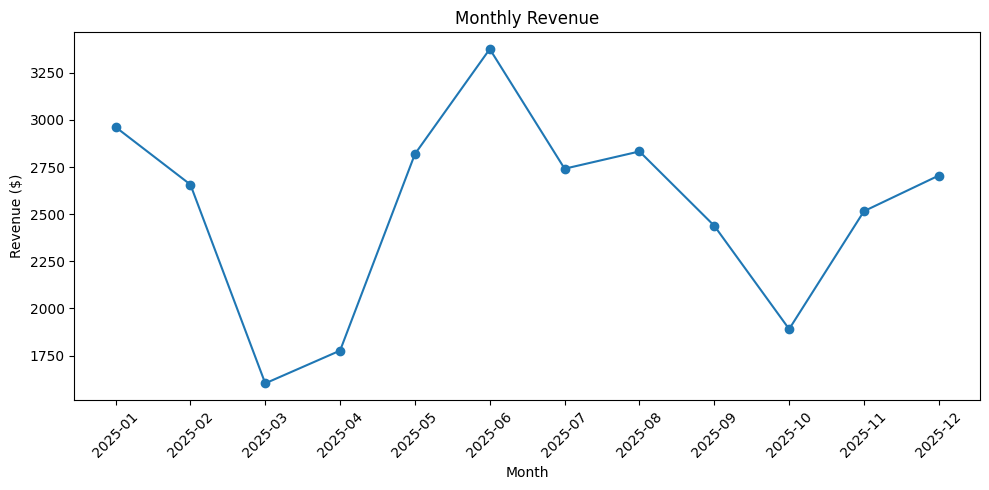

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['month'], monthly_sales['revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Regional Performance

In [ ]:
region_performance = (
    df.groupby('region', as_index=False)
      .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), units=('quantity', 'sum'))
      .sort_values('revenue', ascending=False)
)
region_performance

,region,revenue,profit,units
2,South,8201.11,4290.61,289
3,West,8197.65,4378.15,335
0,East,7168.05,3886.05,295
1,North,6748.62,3537.12,238


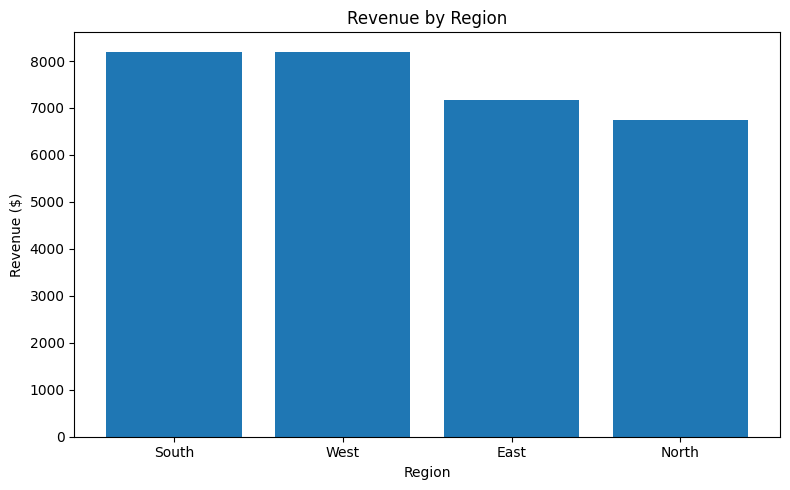

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(region_performance['region'], region_performance['revenue'])
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

## 6. Top Products

In [ ]:
top_products = (
    df.groupby('product', as_index=False)
      .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), units=('quantity', 'sum'))
      .sort_values('revenue', ascending=False)
)
top_products.head(10)

,product,revenue,profit,units
10,Webcam,7078.82,3420.82,118
3,Keyboard,4998.75,2498.75,125
1,Desk Lamp,3118.96,1662.96,104
8,USB-C Hub,2589.26,1257.26,74
7,Storage Box,1931.16,1091.16,84
0,Coffee Mug,1888.74,1258.74,126
2,Desk Organizer,1880.01,1088.01,99
11,Wireless Mouse,1724.31,861.81,69
4,Notebook Pack,1701.69,981.19,131
9,Water Bottle,1319.34,824.34,66


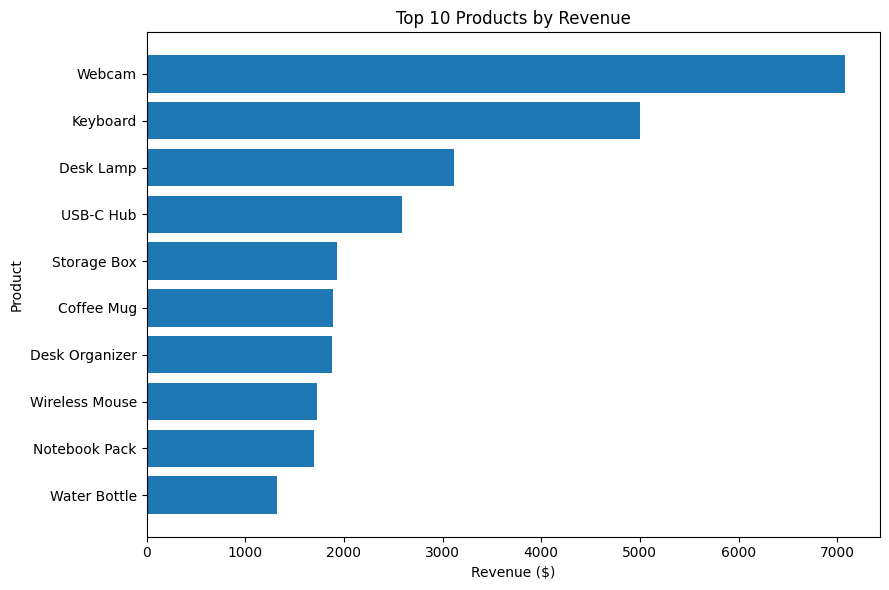

In [ ]:
top_10 = top_products.head(10).sort_values('revenue')
plt.figure(figsize=(9, 6))
plt.barh(top_10['product'], top_10['revenue'])
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

## 7. Category Analysis

In [ ]:
category_performance = (
    df.groupby('category', as_index=False)
      .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), units=('quantity', 'sum'))
      .sort_values('revenue', ascending=False)
)
category_performance

,category,revenue,profit,units
0,Electronics,16391.14,8038.64,386
1,Home,8258.20,4837.20,380
2,Office Supplies,5666.09,3216.09,391


## 8. Top Customers

In [ ]:
top_customers = (
    df.groupby('customer_id', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
      .head(10)
)
top_customers

,customer_id,revenue
4,C1005,1164.51
25,C1026,994.68
57,C1058,986.69
59,C1060,960.74
55,C1056,908.66
45,C1046,864.60
22,C1023,862.73
18,C1019,839.82
52,C1053,819.72
6,C1007,810.74


## 9. Business Questions Answered

- What is the total revenue and profit?
- What is the average order value?
- Which months generate the most revenue?
- Which region performs best?
- Which products and categories generate the most revenue?
- Which customers contribute the most revenue?

## Conclusion

This analysis provides a clear view of sales performance and can help support decisions related to product strategy, regional performance, customer targeting, and profitability.